In [ ]:
# Hafta 6


# Konular:
    ## Dağınık kodunuzu sınıflara toplamak
        ### Linear, BatchNorm1d, Tanh, Embedding, Flatten ve Sequential'ı elle yazmak (torch.nn'i implemente etmek)
    ## Bağlam penceresini 3 harften 8 harfe çıkarmak ve 2'şer 2'şer birleştiren bir ağaç (Wavenet) kurmak
        ### Bkz. DeepMind'ın 2016'daki WaveNet mimarisi.


# Bu hafta öğrenilecekler:  
    ## Kendi katman sınıflarını yazmak: Linear, BatchNorm1d, Tanh, Embedding, Flatten, Sequential
    ## torch.nn'in içinde ne olduğu: çağrılabilir katman, parameters(), eğitim ve tahmin kipi
    ## Bağlamı büyütmenin tek başına yetmediği, harflerin nasıl birleştirildiğinin de sonucu değiştirdiği
    ## Hiyerarşik birleştirme: 8 harfi ikişer ikişer, katman katman karıştırmak
    ## Üç boyutlu tensörde BatchNorm: ortalama hangi eksenlerde alınır ve gözden kaçan hata nerede
    ## Tensor şekillerini takip etmek, PyTorch belgelerini okumak, deney kurmak
    



# Bu haftanin görevleri:
    ## 1. Hafta 4'te yazdığın MLP + BatchNorm kodunu sınıflara topla: Linear, BatchNorm1d, Tanh, Embedding, Flatten, Sequential. Model tek bir Sequential olsun, eğitim döngüsü içindeki katmanların adını bilmesin. Loss eğrisi çizimini videodaki gibi düzelt. (1:40 - 17:11)
    ## 2. Bağlamı 3 harften 8'e çıkar. Başka hiçbir şeyi değiştirmeden aynı düz modeli koş, dev loss'u kaydet. Bu senin karşılaştırma tabanın. Parametre sayısı ne kadar arttı, loss ne kadar düştü, yaz. (17:11 - 21:36)
    ## 3. WaveNet'i kur. 8 harfi tek seferde düzleştirmek yerine ikişer ikişer birleştir, üç katmanda tek vektöre in. Her katmanın çıktısının şeklini yazdır ve o şeklin neden öyle olduğunu kendi cümlelerinle yaz. (21:36 - 37:41)
    ## 4. Şekilleri yazdırırken BatchNorm1d'nin üç boyutlu girdide yanlış çalıştığını göreceksin. Hatanın ne olduğunu ve ortalamanın hangi eksenlerde alınması gerektiğini göster, düzelt, modeli yeniden eğit. Düzeltmeden önceki ve sonraki dev loss'u yan yana koy. (37:41 - 46:07)
    ## 5. Modeli büyüt: embedding boyutunu ve katman genişliğini artır. Tek tablo çıkar, üç satır olsun: bağlam 3 MLP, bağlam 8 düz MLP, bağlam 8 WaveNet. Sütunlar parametre sayısı ve dev loss. (46:07 - 46:58)
    ## 6. Türkçe isim listenle aynı WaveNet'i eğit. Ürettiği isimlerden örnek ver, dev loss'u hafta 4'ün Türkçe MLP'siyle karşılaştır. Türkçe'de bağlamı 8'e çıkarmak ne kazandırdı, yaz

In [ ]:
# hazırlık

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  #print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27
... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


      0/ 200000: 3.3064
  10000/ 200000: 2.4084
  20000/ 200000: 2.1255
  30000/ 200000: 2.0272
  40000/ 200000: 2.5967
  50000/ 200000: 2.0261
  60000/ 200000: 2.2362
  70000/ 200000: 2.2532
  80000/ 200000: 2.2486
  90000/ 200000: 1.8930
 100000/ 200000: 2.1207
 110000/ 200000: 2.0767
 120000/ 200000: 2.1062
 130000/ 200000: 2.1011
 140000/ 200000: 1.9656
 150000/ 200000: 2.2332
 160000/ 200000: 2.3106
 170000/ 200000: 2.4930
 180000/ 200000: 2.0151
 190000/ 200000: 2.4190


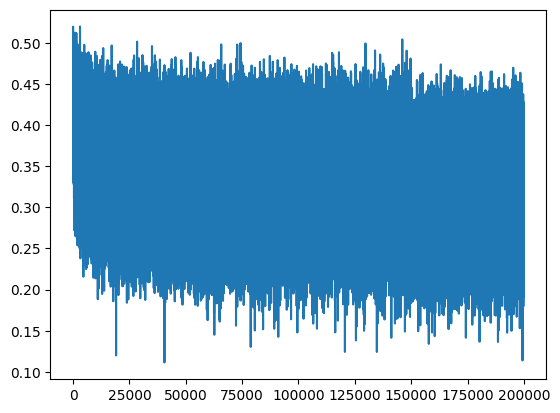

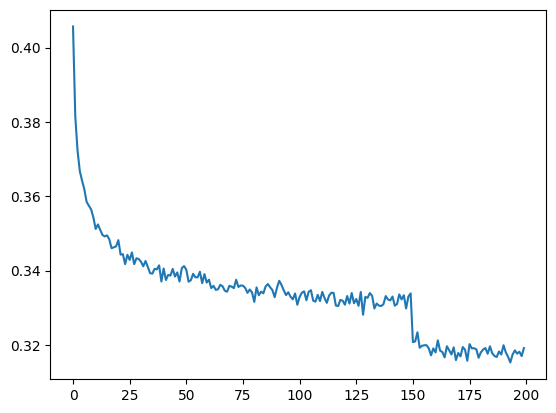

train 2.059309959411621
val 2.1074464321136475


In [ ]:
# Görev 1:
    ## Hafta 4'te yazdığın MLP + BatchNorm kodunu sınıflara topla: 
        ### Linear, BatchNorm1d, Tanh, Embedding, Flatten, Sequential
    ## Model tek bir Sequential olsun, eğitim döngüsü içindeki katmanların adını bilmesin
    ## Loss eğrisi çizimini videodaki gibi düzelt



## => Neden, class NN: ... deyip her şeyi içine atmıyoz?
    ### -> torch.nn'de, "lego parçası" gibi her layer
        #### hangi layer'a ne koncağını elle koyuyorsun
        #### -> ondan, (layer'a konulabilir) her elemen, "bir class"
            ##### Linear, Tanh, BatchNorm vs.
            ##### Örnek kullanım:
                ###### Embedding(), Flatten(), Linear(), BatchNorm1d(), Tanh(), Linear(), BatchNorm1d()


# kodu sınıflara toplama
class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.W = torch.randn((fan_in, fan_out)) / fan_in ** 0.5 ## kaiming init
        self.b = torch.zeros(fan_out) if bias else None
    
    def __call__(self,x):
        if self.b is not None:
            self.out = x @ self.W + self.b 
        else:
            self.out = x @ self.W
        
        return self.out
    
    def parameters(self):
        if self.b is not None:
            return [self.W, self.b]
        else:
            return [self.W]


class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.training = True
        
        self.eps = eps
        self.momentum = momentum

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    
    def __call__(self,x):
        if self.training:
            xmean = x.mean(0,keepdim=True)
            xvar  = x.var(0,keepdim=True)
        else:
            xmean = self.running_mean
            xvar  = self.running_var

        self.out = self.gamma * ( (x - xmean) / torch.sqrt(xvar + self.eps) ) + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var  = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []


class Embedding:
    def __init__(self,num_embeddings, n_dim):
        ## => Neden "vocab_size" demedik? (num_embeddings dedik?)
            ### çağırırken vocab_size koyucaz
            ### Ama, "generic" yazmış olmak için böyle koymak lazım
        
        ## => neden karpathy, self.weights diyor??
            ### çünkü, "nn'deki weight'lerin (backprop ettikçe) update olması/gelişmesi" gibi...
            ### bunlar da update oluyormuş !!!
                #### ama ben embs dicem, çünkü neden olmasın :)
        self.embs = torch.randn((num_embeddings,n_dim))
    
    def __call__(self, ix):
        self.out = self.embs[ix]
        return self.out
    
    def parameters(self):
        return [self.embs]


class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0],-1)
        return self.out
    
    def parameters(self):
        return []


class Sequential:
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        
    def __init__(self, layers):
        self.layers = layers

        ## videoda bu yok, ben buraya koydum ama
        for p in self.parameters():
            p.requires_grad = True
        parameters = model.parameters()

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    




# modeli tek bir sequential yapmak
## videoaki değerler
n_embd = 10
n_hidden = 200

layers = [
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(block_size*n_embd,n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden,vocab_size)
]

model = Sequential(layers)


def train_model(verbose=False):
    with torch.no_grad():
        layers[-1].W *= 0.1     
    parameters = model.parameters()

    ## videodaki değerler
    batch_size = 32
    max_steps = 200000
    lossi = []

    for i in range(max_steps):
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))
        Xb, Yb = Xtr[ix], Ytr[ix]

        """
        x = Xb
        for layer in layers:
            x = layer(x)
        """
        ## benim eklemem

        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb)


        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()
        
        lr = 0.1 if i < 150000 else 0.01 
        for p in parameters:
            p.data += -lr * p.grad

        if i % 10000 == 0 and verbose:
            print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        lossi.append(loss.log10().item())

    if verbose:
        # sorunlu plot
            ## => neden sorunlu?
                ### batch_size = 32 çok az
                ### ondan, çok lucky-unlucky olabilirsin
                ### ondan, stable değil... çok geniş 
        plt.plot(lossi)
        plt.show()

        # basit çözüm: "loss bakma - ortalama loss'a bak"
            ## her adımda loss bakma
            ## her 1000 adımda bir loss bak
                #### -> (!!!) "ortalama loss"a bak (o aralıktaki)
        plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
        plt.show()

    eval_mode()


def eval_mode():
    # put layers into eval mode (needed for batchnorm especially)
    for layer in model.layers:
        layer.training = False

@torch.no_grad() 
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

train_model(verbose=True)
split_loss('train')
split_loss('val')

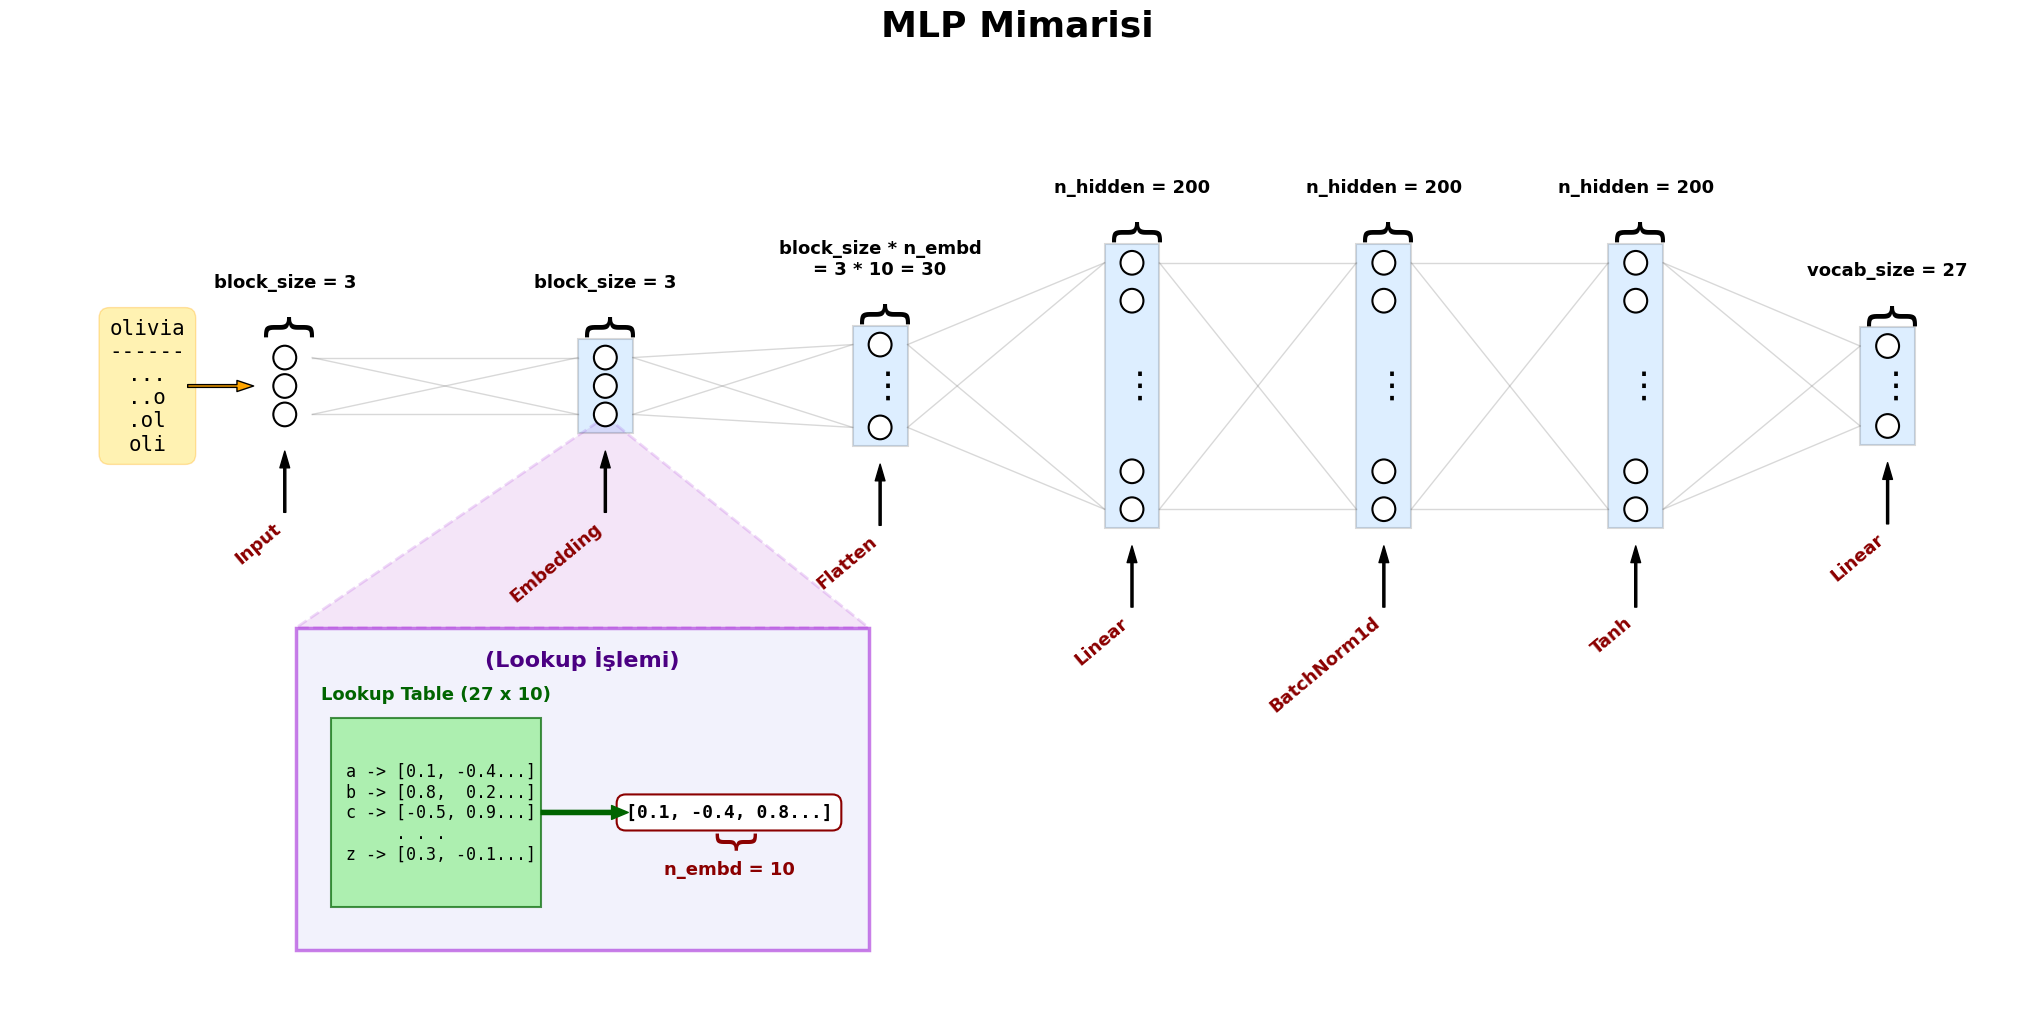

In [ ]:
# görselleştirme
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_nn(layers, block_size=3, n_embd=10, n_hidden=200, vocab_size=27): 
    fig, ax = plt.subplots(figsize=(26, 12)) 
    ax.axis('off') 
    
    sizes = [
        block_size, 
        block_size, 
        block_size * n_embd, 
        n_hidden, 
        n_hidden, 
        n_hidden, 
        vocab_size
    ]
    
    labels = [
        f"block_size = {block_size}",
        f"block_size = {block_size}", 
        f"block_size * n_embd\n= {block_size} * {n_embd} = {block_size * n_embd}", 
        f"n_hidden = {n_hidden}",
        f"n_hidden = {n_hidden}",
        f"n_hidden = {n_hidden}",
        f"vocab_size = {vocab_size}"
    ]
        
    layer_names = ["Input"] + [layer.__class__.__name__ for layer in layers]
    
    x_positions = [0, 7.0, 13.0, 18.5, 24.0, 29.5, 35.0]
    
    min_s, max_s = min(sizes), max(sizes)
    layer_y_positions = []
    
    embedding_neuron_x = 0
    embedding_neuron_y = 0
    
    for i, (name, size, label) in enumerate(zip(layer_names, sizes, labels)):
        x = x_positions[i]
        
        if max_s == min_s:
            box_h = 4.0
        else:
            box_h = 2.0 + (size - min_s) / (max_s - min_s) * (6.0 - 2.0)
            
        current_box_w = 1.2 
        
        if i > 0:
            rect = patches.Rectangle((x - current_box_w/2, -box_h/2), current_box_w, box_h, 
                                     linewidth=1.5, edgecolor='black', facecolor='dodgerblue', alpha=0.15)
            ax.add_patch(rect)
            
        if size <= 4:
            if size == 1:
                y_positions = [0.0]
            else:
                step = (box_h - 0.8) / (size - 1)
                y_positions = [ (box_h / 2 - 0.4) - j*step for j in range(size) ]
            draw_ellipsis = False
        else:
            y_top_c = box_h / 2 - 0.4
            y_bot_c = -box_h / 2 + 0.4
            
            if box_h < 3.5:
                y_positions = [y_top_c, y_bot_c]
            else:
                y_positions = [y_top_c, y_top_c - 0.8, y_bot_c + 0.8, y_bot_c]
            
            draw_ellipsis = True
            
        layer_y_positions.append(y_positions)
        
        for y in y_positions:
            circle = patches.Circle((x, y), radius=0.25, facecolor='white', edgecolor='black', lw=1.5, zorder=3)
            ax.add_patch(circle)
            
        if draw_ellipsis:
            ax.text(x, 0, r'$\vdots$', fontsize=26, ha='center', va='center')
        
        if i == 1:
            embedding_neuron_x = x
            embedding_neuron_y = y_positions[-1]

        brace_y = box_h/2 + 0.4
        label_y = box_h/2 + 1.0
        
        ax.text(x, brace_y, '}', fontsize=38, rotation=90, ha='center', va='center', color='black')
        ax.text(x, label_y, label, fontsize=13, fontweight='bold', ha='center', va='bottom', color='black')
        
        arrow_start_y = -box_h/2 - 0.3
        text_y = -box_h/2 - 1.8
        ax.annotate(name, 
                    xy=(x, arrow_start_y), 
                    xytext=(x, text_y),
                    arrowprops=dict(facecolor='black', width=1.5, headwidth=7, shrink=0.05),
                    fontsize=13, fontweight='bold', color='darkred',
                    ha='right', va='top', rotation=40, zorder=5)
                    
    # --- 4. INPUT VERİSİ ---
    sliding_text = (
        "olivia\n"
        "------\n"
        "...\n"
        "..o\n"
        ".ol\n"
        "oli"
    )
    ax.text(-3.0, 0, sliding_text, fontsize=15, family='monospace', ha='center', va='center', 
            bbox=dict(boxstyle="round,pad=0.5", facecolor='gold', edgecolor='orange', alpha=0.3))
            
    ax.annotate("", xy=(-0.6, 0), xytext=(-2.2, 0),
                arrowprops=dict(facecolor='orange', shrink=0.05, width=2, headwidth=8))

    # --- 5. EXPAND (BÜYÜTEÇ) KUTUSU VE IŞIN EFEKTİ ---
    # Kutunun konumu ve boyutları (İç içe geçmemesi için boyunu uzattım)
    eb_cx = 6.5
    eb_cy = -8.5
    eb_w = 12.5
    eb_h = 6.8
    eb_top = eb_cy + eb_h/2
    eb_bot = eb_cy - eb_h/2
    eb_left = eb_cx - eb_w/2
    eb_right = eb_cx + eb_w/2

    poly = patches.Polygon([
        (embedding_neuron_x - 0.15, embedding_neuron_y - 0.15),
        (eb_left, eb_top),                                      
        (eb_right, eb_top),                                     
        (embedding_neuron_x + 0.15, embedding_neuron_y - 0.15)  
    ], closed=True, facecolor='mediumorchid', alpha=0.15, edgecolor='darkviolet', linestyle='--', lw=2, zorder=0)
    ax.add_patch(poly)
    
    rect_eb = patches.Rectangle((eb_left, eb_bot), eb_w, eb_h,
                                linewidth=2.5, edgecolor='darkviolet', facecolor='lavender', alpha=0.5, zorder=1)
    ax.add_patch(rect_eb)
    
    # Kutunun Başlığı
    ax.text(eb_cx, eb_top - 0.4, "(Lookup İşlemi)", fontsize=16, fontweight='bold', color='indigo', ha='center', va='top', zorder=2)

    # --- 5.a LOOKUP TABLE ---
    # Tablonun genişliği (table_w) 3.6'dan 4.6'ya çıkarıldı
    table_x = eb_cx - 3.2
    table_y = eb_cy - 0.5
    table_w, table_h = 4.6, 4.0 
    rect_table = patches.Rectangle((table_x - table_w/2, table_y - table_h/2), table_w, table_h,
                                   linewidth=1.5, edgecolor='darkgreen', facecolor='lightgreen', alpha=0.7, zorder=2)
    ax.add_patch(rect_table)
    
    table_content = (
        " a -> [0.1, -0.4...]\n"
        " b -> [0.8,  0.2...]\n"
        " c -> [-0.5, 0.9...]\n"
        "      . . .         \n"
        " z -> [0.3, -0.1...]"
    )
    ax.text(table_x, table_y, table_content, fontsize=12, family='monospace', ha='center', va='center', zorder=3)
    table_title = f"Lookup Table ({vocab_size} x {n_embd})"
    ax.text(table_x, table_y + table_h/2 + 0.3, table_title, fontsize=13, fontweight='bold', ha='center', va='bottom', color='darkgreen', zorder=3)
    
    # --- 5.b ZOOMED VECTOR ---
    zoom_x = eb_cx + 3.2
    zoom_y = table_y
    
    ax.text(zoom_x, zoom_y, "[0.1, -0.4, 0.8...]", fontsize=13, fontweight='bold', family='monospace', ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='darkred', lw=1.5), zorder=3)
            
    ax.text(zoom_x, zoom_y - 0.7, '}', fontsize=32, rotation=-90, ha='center', va='center', color='darkred', zorder=3)
    ax.text(zoom_x, zoom_y - 1.2, f"n_embd = {n_embd}", fontsize=13, fontweight='bold', ha='center', va='center', color='darkred', zorder=3)

    # --- 5.c İÇ OK (Table -> Vector) ---
    # Okun ucu kutunun içine girmesin diye "zoom_x - 2.2" yapılarak biraz daha geride durduruldu
    zoom_box_left_edge = zoom_x - 2.2 
    table_right_edge = table_x + table_w/2 
    ax.annotate("", xy=(zoom_box_left_edge, zoom_y), xytext=(table_right_edge, zoom_y),
                arrowprops=dict(facecolor='darkgreen', width=3, headwidth=10, edgecolor='darkgreen'), zorder=3)

    # --- 6. KATMANLAR ARASI BAĞLANTI ÇİZGİLERİ ---
    for i in range(len(layer_names) - 1):
        x = x_positions[i]
        next_x = x_positions[i+1]
        
        current_w = 1.2
        next_w = 1.2
        
        current_ys = [layer_y_positions[i][0], layer_y_positions[i][-1]]
        next_ys = [layer_y_positions[i+1][0], layer_y_positions[i+1][-1]]
        
        start_x = x + current_w/2
        end_x = next_x - next_w/2
        
        for y_start in current_ys:
            for y_end in next_ys:
                ax.plot([start_x, end_x], [y_start, y_end], color='gray', alpha=0.3, lw=1)
                    
    ax.set_xlim(-6.0, x_positions[-1] + 3)
    ax.set_ylim(-13.0, 6.5) 
    
    plt.title("MLP Mimarisi", fontsize=26, fontweight='bold', pad=30)
    plt.show()

# Kodu çalıştırıyoruz
visualize_nn(layers, block_size=block_size, n_embd=n_embd, n_hidden=n_hidden, vocab_size=vocab_size)

In [ ]:
# Görev 2:
    ## Bağlamı 3 harften 8'e çıkar
    ## Başka hiçbir şeyi değiştirmeden aynı düz modeli koş, dev loss'u kaydet 
    ## Şunları yaz:
        ### Parametre sayısı ne kadar arttı
        ### Loss ne kadar düştü


## eski parametre sayısı 
old_param_count = sum(p.nelement() for p in model.parameters())

block_size = 8
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

layers = [
    Embedding(vocab_size, n_embd),
    Flatten(),
    Linear(block_size*n_embd,n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden,vocab_size)
]

model = Sequential(layers)

## yeni parametre sayısı 
new_param_count = sum(p.nelement() for p in model.parameters())
print(f"Eski parametre sayısı: {old_param_count}  -  Yeni parametre sayısı: {new_param_count}")

train_model()

split_loss('train')
split_loss('val')

Eski parametre sayısı: 12097  -  Yeni parametre sayısı: 22097
train 1.9183646440505981
val 2.0214710235595703


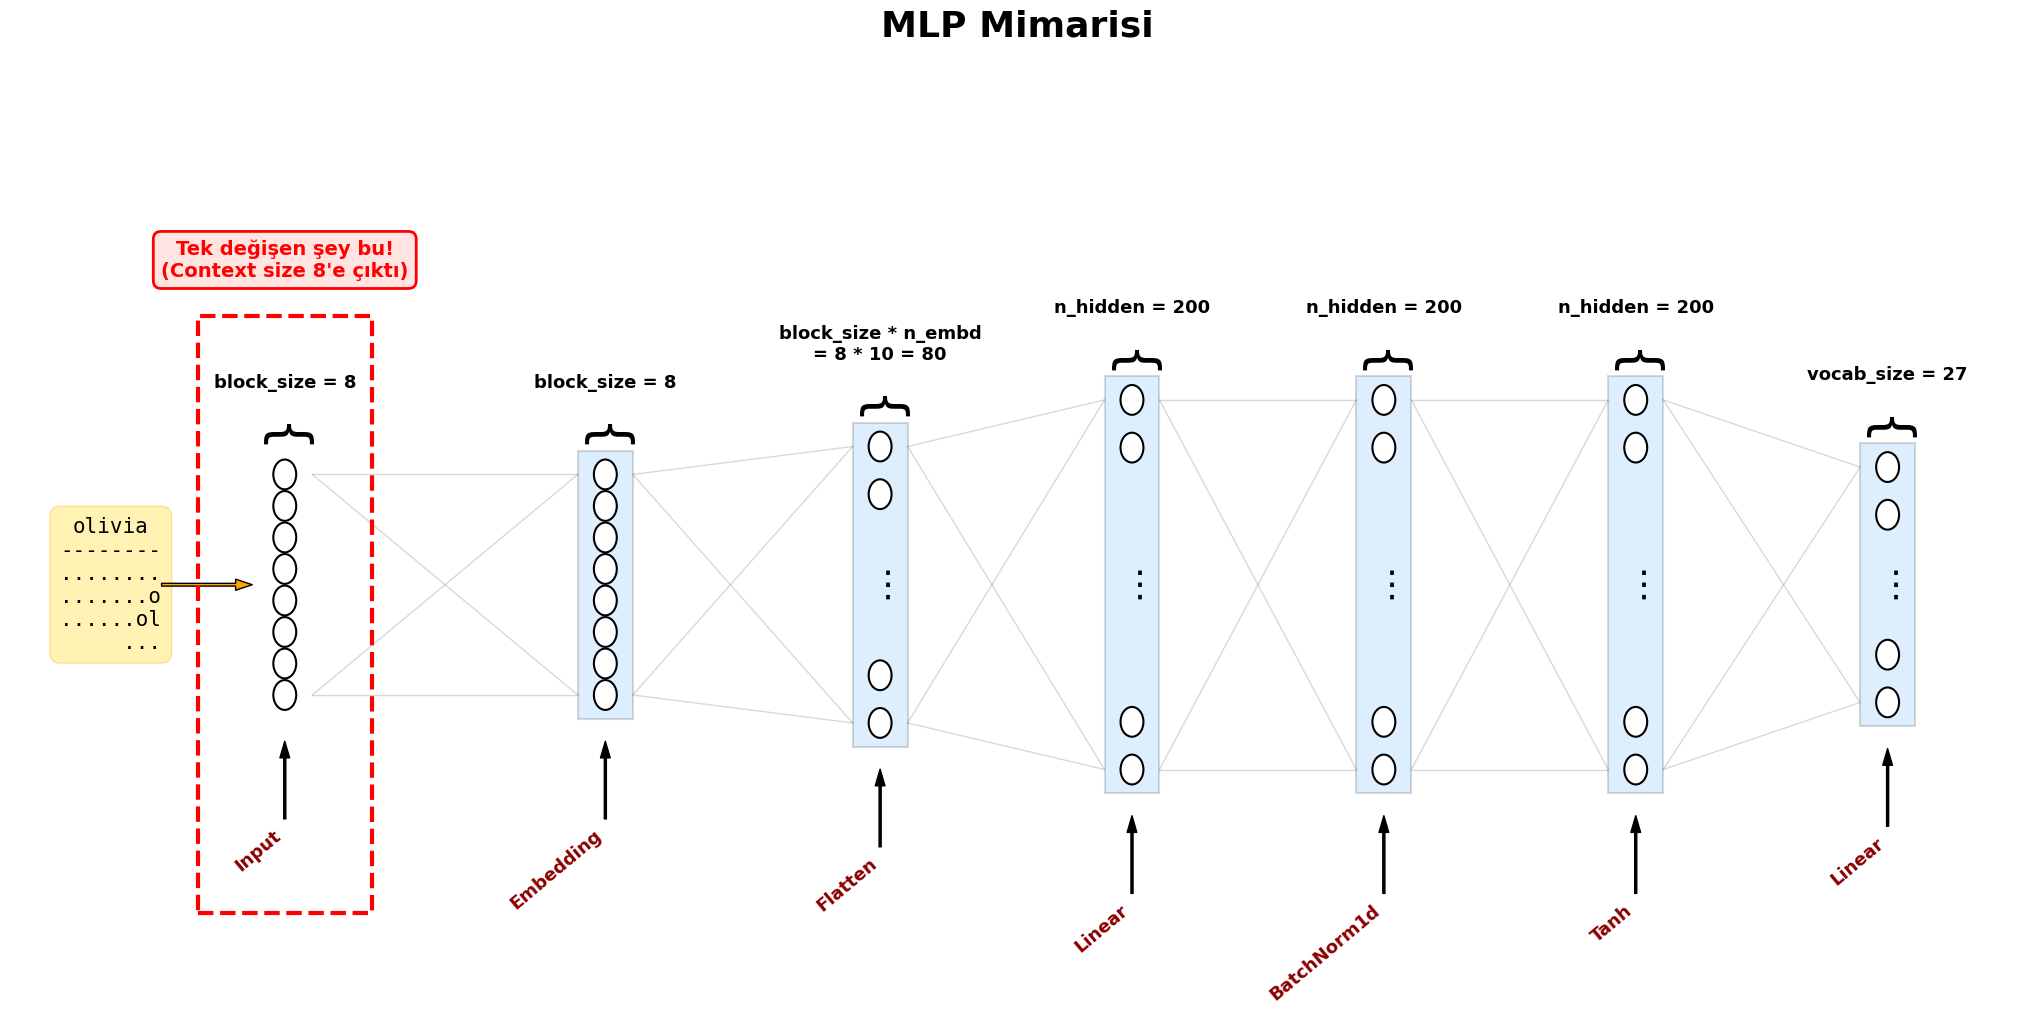

In [ ]:
# görselleştirme
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_nn_block8(layers, block_size=8, n_embd=10, n_hidden=200, vocab_size=27): 
    fig, ax = plt.subplots(figsize=(26, 12)) 
    ax.axis('off') 
    
    sizes = [
        block_size, 
        block_size, 
        block_size * n_embd, 
        n_hidden, 
        n_hidden, 
        n_hidden, 
        vocab_size
    ]
    
    labels = [
        f"block_size = {block_size}",
        f"block_size = {block_size}", 
        f"block_size * n_embd\n= {block_size} * {n_embd} = {block_size * n_embd}", 
        f"n_hidden = {n_hidden}",
        f"n_hidden = {n_hidden}",
        f"n_hidden = {n_hidden}",
        f"vocab_size = {vocab_size}"
    ]
        
    layer_names = ["Input"] + [layer.__class__.__name__ for layer in layers]
    
    x_positions = [0, 7.0, 13.0, 18.5, 24.0, 29.5, 35.0]
    
    min_s, max_s = min(sizes), max(sizes)
    layer_y_positions = []
    
    for i, (name, size, label) in enumerate(zip(layer_names, sizes, labels)):
        x = x_positions[i]
        
        if max_s == min_s:
            box_h = 5.0
        else:
            box_h = 4.5 + (size - min_s) / (max_s - min_s) * (7.0 - 4.5)
            
        current_box_w = 1.2 
        
        if i > 0:
            rect = patches.Rectangle((x - current_box_w/2, -box_h/2), current_box_w, box_h, 
                                     linewidth=1.5, edgecolor='black', facecolor='dodgerblue', alpha=0.15)
            ax.add_patch(rect)
            
        if size <= 8:
            step = (box_h - 0.8) / (size - 1) if size > 1 else 0
            y_positions = [ (box_h / 2 - 0.4) - j*step for j in range(size) ]
            draw_ellipsis = False
        else:
            y_top_c = box_h / 2 - 0.4
            y_bot_c = -box_h / 2 + 0.4
            
            y_positions = [y_top_c, y_top_c - 0.8, y_bot_c + 0.8, y_bot_c]
            draw_ellipsis = True
            
        layer_y_positions.append(y_positions)
        
        for y in y_positions:
            circle = patches.Circle((x, y), radius=0.25, facecolor='white', edgecolor='black', lw=1.5, zorder=3)
            ax.add_patch(circle)
            
        if draw_ellipsis:
            ax.text(x, 0, r'$\vdots$', fontsize=26, ha='center', va='center')

        brace_y = box_h/2 + 0.4
        label_y = box_h/2 + 1.0
        
        ax.text(x, brace_y, '}', fontsize=38, rotation=90, ha='center', va='center', color='black')
        ax.text(x, label_y, label, fontsize=13, fontweight='bold', ha='center', va='bottom', color='black')
        
        arrow_start_y = -box_h/2 - 0.3
        text_y = -box_h/2 - 1.8
        ax.annotate(name, 
                    xy=(x, arrow_start_y), 
                    xytext=(x, text_y),
                    arrowprops=dict(facecolor='black', width=1.5, headwidth=7, shrink=0.05),
                    fontsize=13, fontweight='bold', color='darkred',
                    ha='right', va='top', rotation=40, zorder=5)
                    
        # --- KIRMIZI ÇERÇEVE VE AÇIKLAMA (Sadece Input katmanında) ---
        if i == 0:
            frame_w = 3.8 # 3.0'dan 3.8'e çıkardık, yanlardan bol bol genişledi
            frame_y = -5.5
            frame_h = 10.0
            frame_x = x - frame_w/2
            
            rect_frame = patches.Rectangle((frame_x, frame_y), frame_w, frame_h,
                                           linewidth=3, edgecolor='red', facecolor='none', linestyle='--', zorder=10)
            ax.add_patch(rect_frame)
            
            # Üzerindeki Not (+0.6 yaparak biraz daha yukarı kaldırdık)
            ax.text(x, frame_y + frame_h + 0.6, "Tek değişen şey bu!\n(Context size 8'e çıktı)", 
                    fontsize=14, fontweight='bold', color='red', ha='center', va='bottom',
                    bbox=dict(boxstyle="round,pad=0.4", facecolor='mistyrose', edgecolor='red', lw=2))

    # --- 4. INPUT VERİSİ (Sarı kutuyu da sola kaydırdık ki kırmızı çerçeve ile sıkışmasın) ---
    sliding_text = (
        "olivia\n"
        "--------\n"
        "........\n"
        ".......o\n"
        "......ol\n"
        "     ..."
    )
    ax.text(-3.8, 0, sliding_text, fontsize=15, family='monospace', ha='center', va='center', 
            bbox=dict(boxstyle="round,pad=0.5", facecolor='gold', edgecolor='orange', alpha=0.3))
            
    ax.annotate("", xy=(-0.6, 0), xytext=(-2.8, 0),
                arrowprops=dict(facecolor='orange', shrink=0.05, width=2, headwidth=8))

    # --- 6. KATMANLAR ARASI BAĞLANTI ÇİZGİLERİ ---
    for i in range(len(layer_names) - 1):
        x = x_positions[i]
        next_x = x_positions[i+1]
        
        current_w = 1.2
        next_w = 1.2
        
        current_ys = [layer_y_positions[i][0], layer_y_positions[i][-1]]
        next_ys = [layer_y_positions[i+1][0], layer_y_positions[i+1][-1]]
        
        start_x = x + current_w/2
        end_x = next_x - next_w/2
        
        for y_start in current_ys:
            for y_end in next_ys:
                ax.plot([start_x, end_x], [y_start, y_end], color='gray', alpha=0.3, lw=1)
                    
    ax.set_xlim(-6.0, x_positions[-1] + 3)
    ax.set_ylim(-7.0, 8.5) 
    
    plt.title("MLP Mimarisi", fontsize=26, fontweight='bold', pad=30)
    plt.show()

# Kodu çalıştırıyoruz (block_size = 8 ile)
visualize_nn_block8(layers, block_size=8, n_embd=n_embd, n_hidden=n_hidden, vocab_size=vocab_size)

In [ ]:
# Görev 3:
    ## WaveNet'i kur
    ## 8 harfi tek seferde düzleştirmek yerine ikişer ikişer birleştir, üç katmanda tek vektöre in 
    ## Her katmanın çıktısının şeklini yazdır
    ## O şeklin, neden öyle olduğunu kendi cümlelerinle yaz


class FlattenConsecutive :
    def __init__(self,n):
        self.n = n
    
    def __call__(self,x):
        B,T,C = x.shape
        x= x.view(B, T//self.n, C*self.n)

        if x.shape[1] == 1:
            x = x.squeeze(1)
        
        self.out = x
        return self.out
    
    def parameters(self):
        return []
# wavenet
    ## "embeddingler -> layer" yerine
    ## "embedding grubu -> layer" yapıyor
        ### embedding: oooooooo olsun
            ### normalde: ooooooo -> layer
            ### (!!) wavenet'te:
                #### oo oo oo oo gibi gruplara/convolution'lara ayırıyon
                #### oo -> layer a girdi.... diğer "    oo oo oo oo"lar ile etkileşime girmedi
            ### -> squash etmedik, tüm embeddding'leri tek seferde
            ### -> her adımda 2 embedding fuse'ladık/birleştirdik
                #### ilk layer 2 char
                #### sonraki layer 2 bigram
                #### sonra 2 fourgram vs.

                
# FlattenConsecutive
    ## x.shape = x.shape(B.shape, T.shape // n, C.shape * n) oldu
            #### B,T,C = x.shape oldu
            #### n = block_size
        ### (4,12,10)  === ise ===> (4,6,20) oldu
            ### (4,12,10)
                ####  4: örnek sayısı
                #### 12: (her bir örnekteki) grup sayısı
                #### 16: gruplardaki char sayısı
            ### => eskiden nasıldı?
                ####  4: örnek sayısı
                #### 12: (her bir örnekteki) char sayısı
                #### 16: her char'ın embedding'i kaç boyutlu? (n_dim)
                #### -> (!!) sonra, .view(,-1) ile fln eziyorduk
                    ##### sadece 2 boyut kalırdı
                        ###### "(örnek sayısı, char sayısı * n_dim)"
                    ##### -> Wavenet'te ise ezmedik (direkt)
                        ###### GRUP SAYISI 1 KALINCA EZİYORUZ anca
    ## değişiklik sebebi ne?
        ### önceden: (gruplama yok ya - tüm embeddinglere bakılır ya)
            #### [  [a], [b], [c], [d]  ]   =>  shape: (4,1)
        ### şimdi: (2'li grup olduğunu düşün)
            #### [  [a, b], [c, d]  ]       => shape: (2,2)
        ### -> değişikliğin sebebi bu:
            #### -> "grup sayısı azaldı; grup elemanı sayısı arttı."
                ##### önceden, 1 char'lık/embedding'lik gruplar vardı (her bir embedding kendi grubuydu)
                ##### şimdi, bir sürü embedding oldu, bir grup içinde
    ## -> her bi layer sonrası bu var artık
        ### Embedding(), FlattenConsecutive(), Linear(), FlattenConsecutive(), Linear(), FlattenConsecutive(), ...
        ### -> ondan, adım adım bölme bunla oluyor
            ### -> block_size = 8, ilk layer'da değil; her bir layer'da uygulanıyor



## block_size = 8 üstüne data hazırlandı... hala öyle yani
kernel_size = 2


## 3 katmanda tek vektöre iniyoruz
model = Sequential([
    Embedding(vocab_size, n_embd),
    
    ## 8 -> 4
    FlattenConsecutive(kernel_size),
    Linear(n_embd*kernel_size,n_hidden), BatchNorm1d(n_hidden), Tanh(),
        ### => neden FlattenConsecutive (2)'dan sonra, Linear(n_embd * 2) yaptık?
            #### (B, 8, C)    =====  FlattenConsecutive  ===== >   (B, 8//2, C*2) == (B, 4, 2C)
            #### ondan, son 2 layer tam otursun diye

    
    ## 4 -> 2
    FlattenConsecutive(kernel_size),
    Linear(n_hidden*kernel_size,n_hidden), BatchNorm1d(n_hidden), Tanh(),
    
    ## 2 -> 1
    FlattenConsecutive(kernel_size),
    Linear(n_hidden*kernel_size,n_hidden), BatchNorm1d(n_hidden), Tanh(),


    Linear(n_hidden,vocab_size)
])



## Her katmanın şekli
ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
x = Xb

# Sola 20 karakter (<20), Sağa 15 karakter (>15) boşluk ayır
print(f"{'Giriş şekli (Xb)':<20} : {str(tuple(x.shape)):>15}")

for layer in model.layers: 
    x = layer(x)
    
    # layer ismi ve tuple'ı string'e çevirip aynı hizada basıyoruz
    name = layer.__class__.__name__
    shape = str(tuple(x.shape))
    
    print(f"{name:<20} : {shape:>15}")



train_model()

split_loss('train')
split_loss('val')


# sorular
    ## => neden, 4,4,20 => 4,4,200 oldu?
        ### -> flatten() ettik, (2'şerli elemanlı olan) gruplaştırdık ya
            #### (8, 10) -> (4,20) oldu
            #### "1 elemanlı 8 grup"  ===> "2 elemanlı 4 grup"
        ### -> sonra da, Linear(...,n_hidden=200 içeriyo)
            #### ondan, 200 oldu
    ## => nasıl, "n_hidden*2" oldu hep?
            ### hani bi taraf /2 biri *2 ise neden "n_hidden/2, n_hidden*2" gibi olmadı?
        ### -> input olarak hep "n_hidden*kernel_size" veriyoruz ya
            #### Flatten //2 yaparken kernel_size *2 yapıyor... o kısmı koruyor

Giriş şekli (Xb)     :          (4, 8)
Embedding            :      (4, 8, 10)
FlattenConsecutive   :      (4, 4, 20)
Linear               :     (4, 4, 200)
BatchNorm1d          :     (4, 4, 200)
Tanh                 :     (4, 4, 200)
FlattenConsecutive   :     (4, 2, 400)
Linear               :     (4, 2, 200)
BatchNorm1d          :     (4, 2, 200)
Tanh                 :     (4, 2, 200)
FlattenConsecutive   :        (4, 400)
Linear               :        (4, 200)
BatchNorm1d          :        (4, 200)
Tanh                 :        (4, 200)
Linear               :         (4, 27)


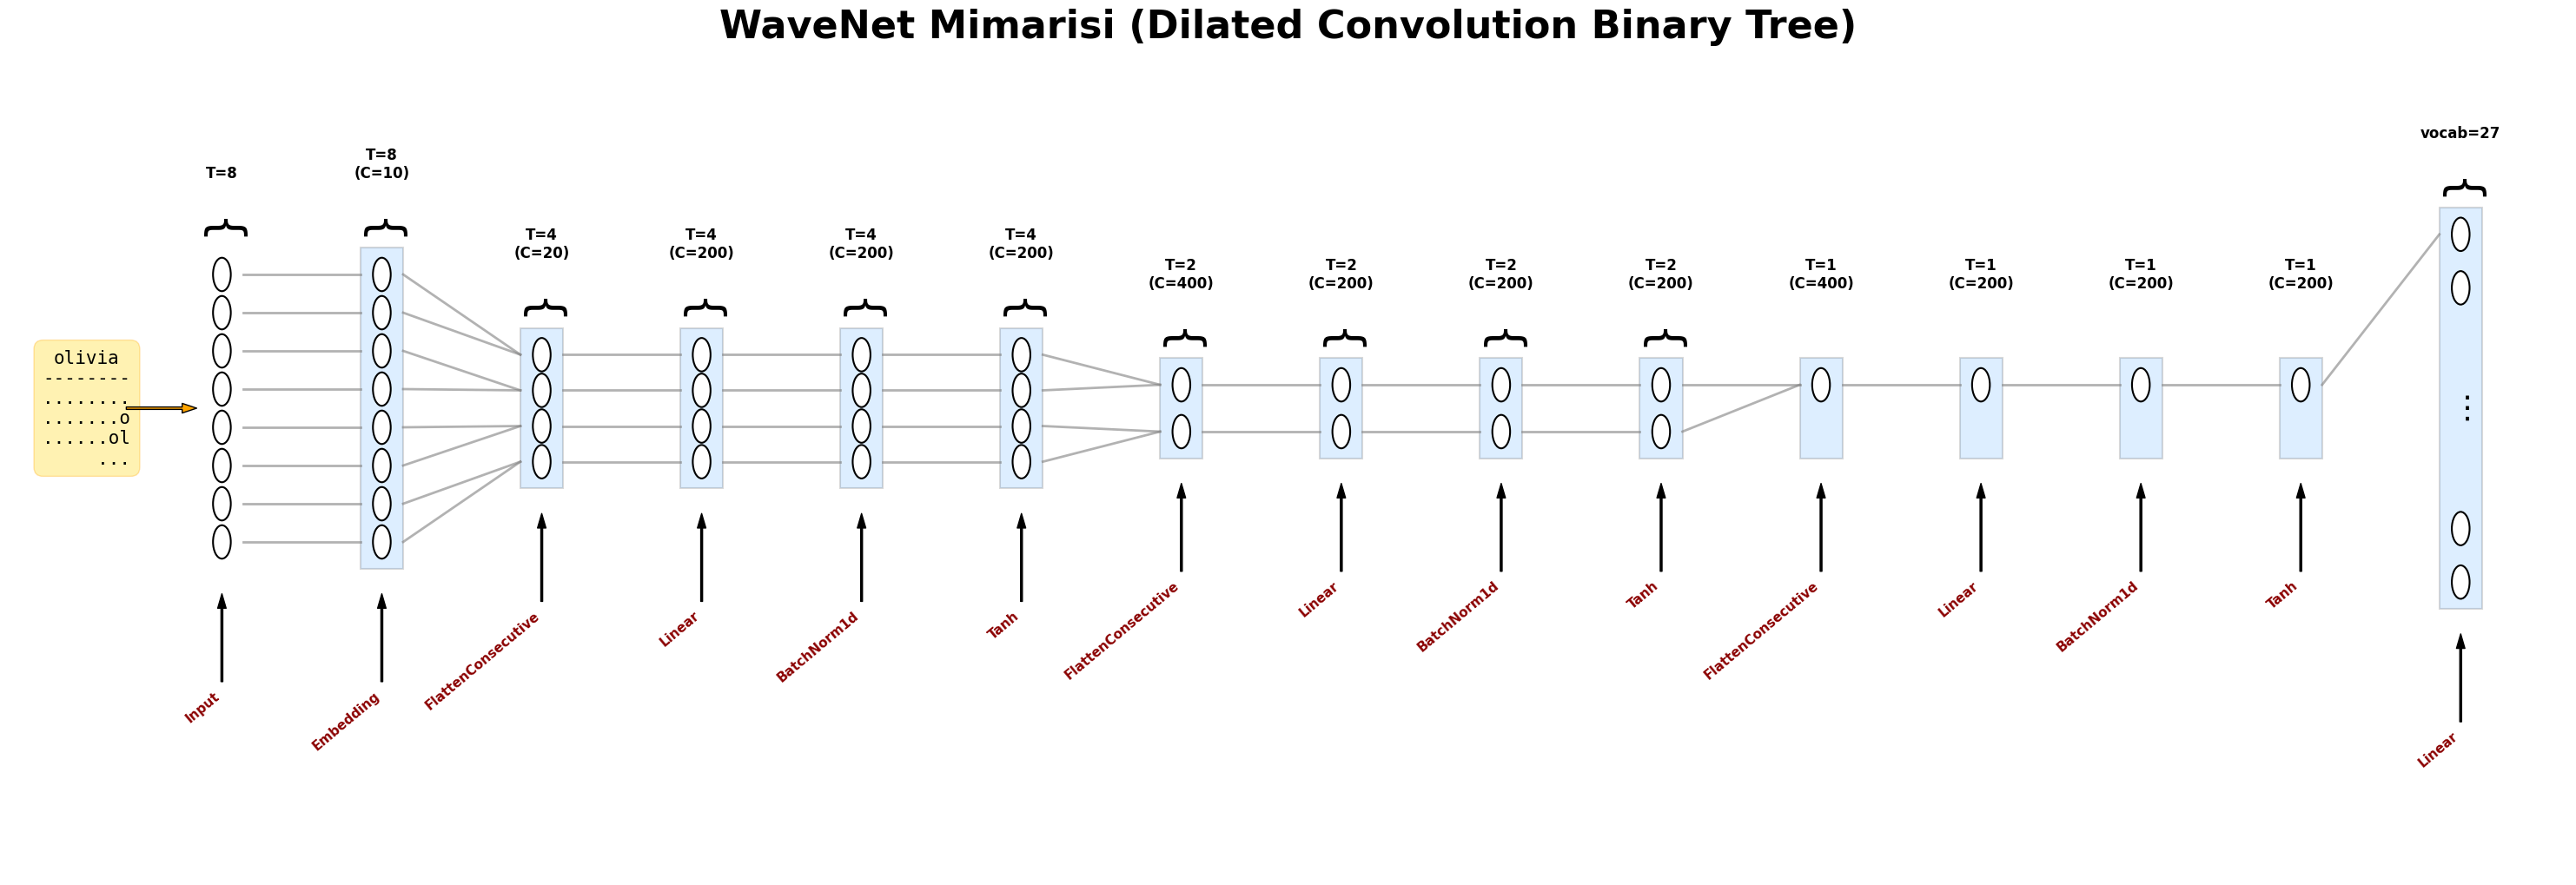

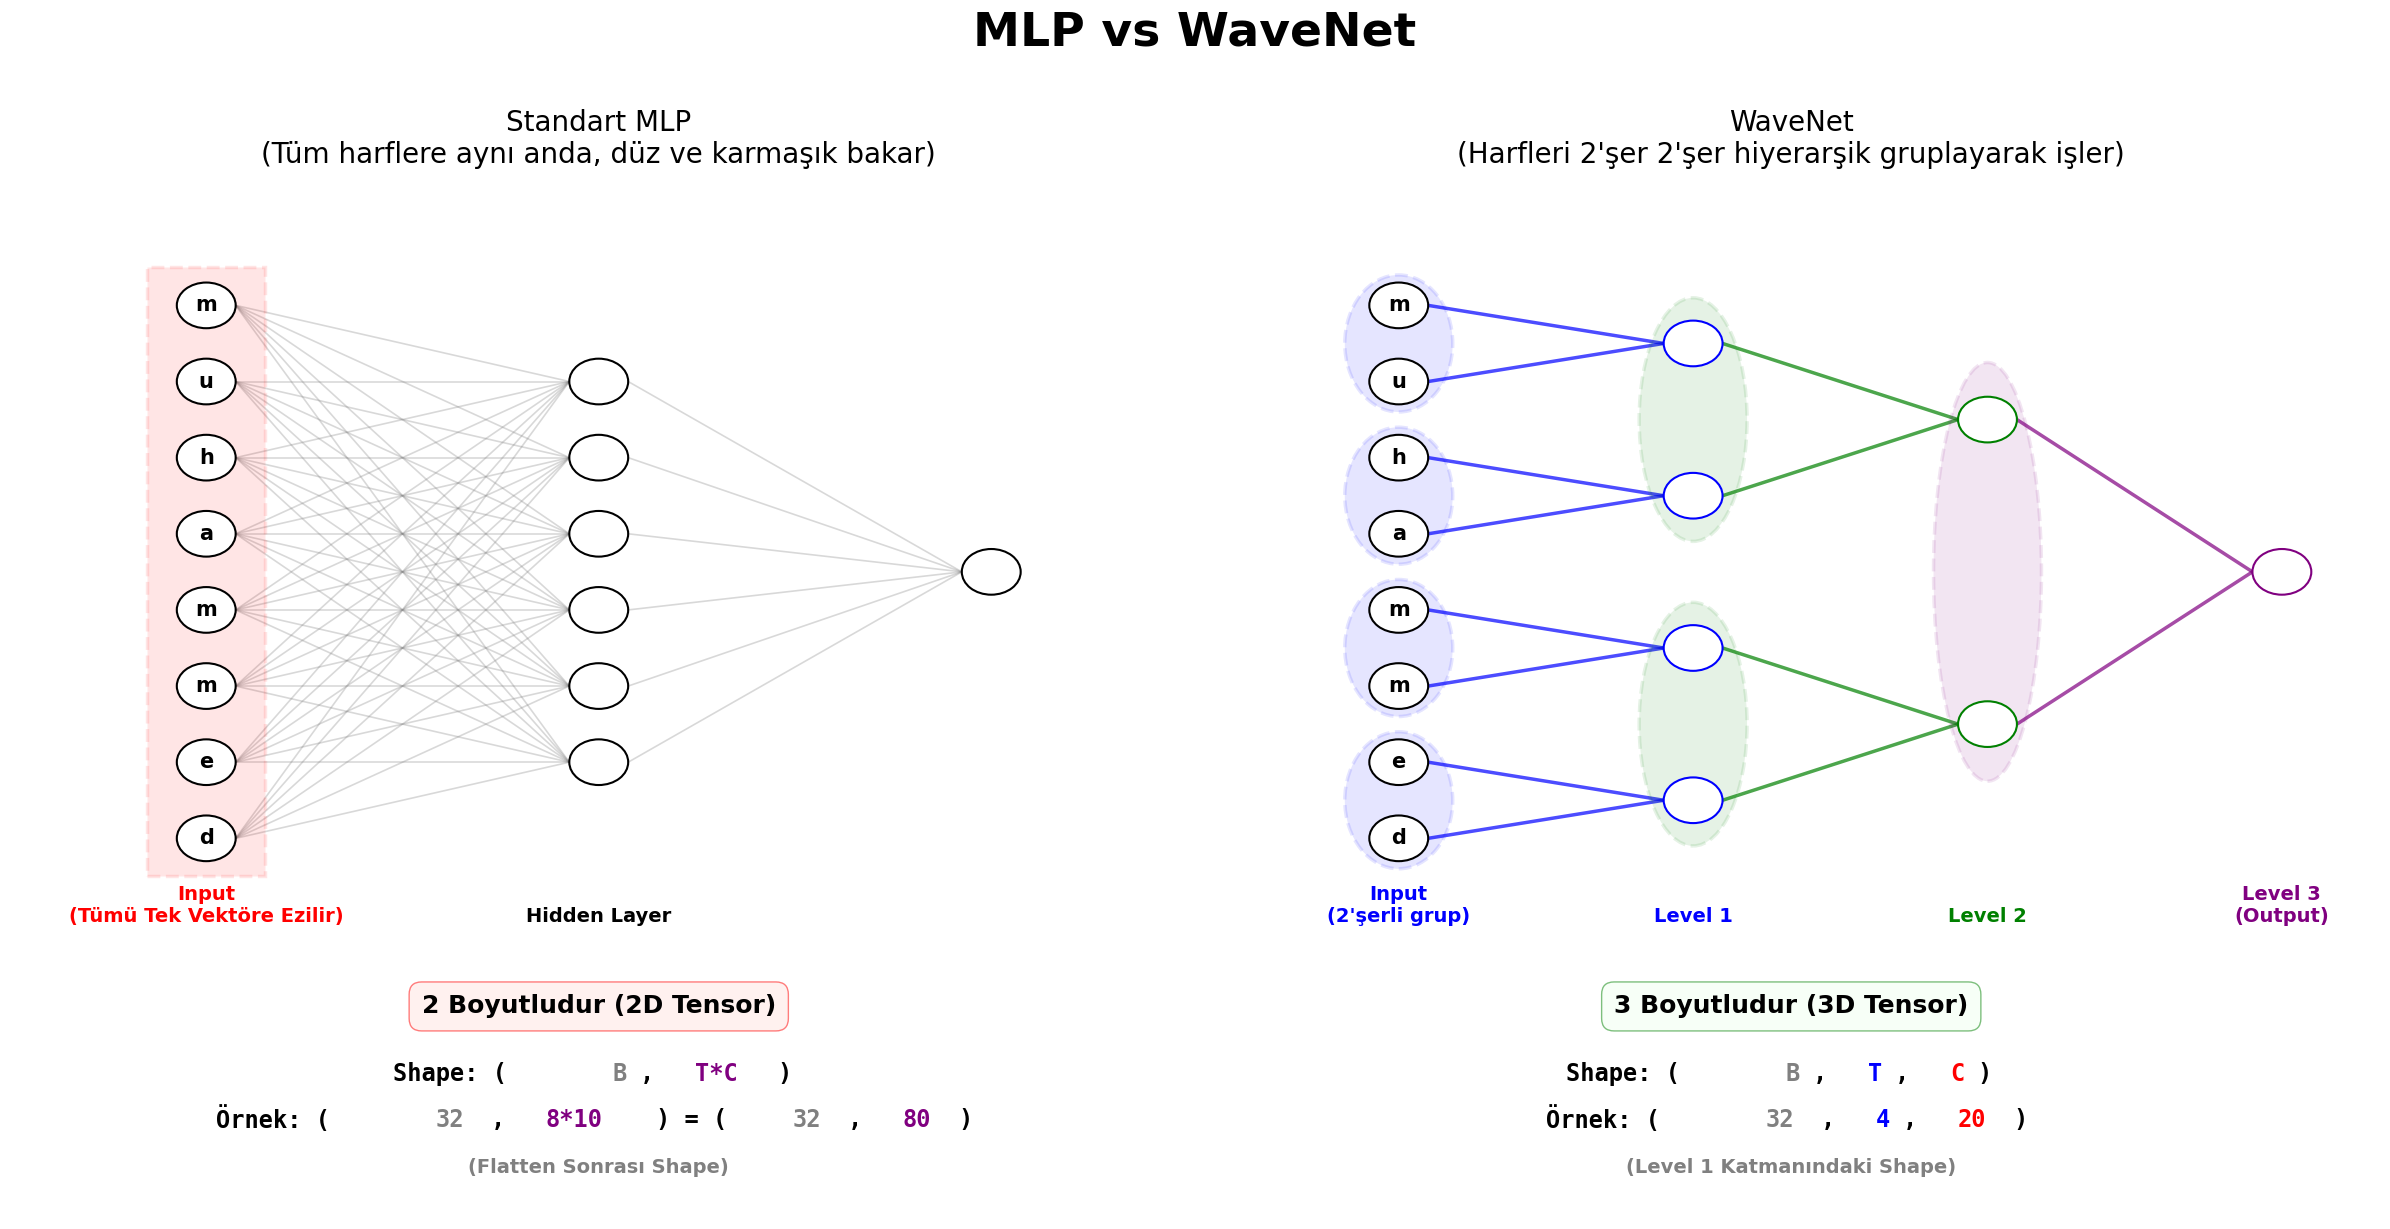

In [ ]:
# görselleştirme
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_wavenet(block_size=8, n_embd=10, n_hidden=200, vocab_size=27): 
    fig, ax = plt.subplots(figsize=(38, 12)) 
    ax.axis('off') 
    
    # WaveNet'in Zaman Adımları (T) ve Çıktı Boyutu
    sizes = [
        8, 8, 
        4, 4, 4, 4, 
        2, 2, 2, 2, 
        1, 1, 1, 1, 
        27
    ]
    
    # Her adımda Zaman Adımı (T) ve Kanal/Feature (C) sayısını gösteren etiketler
    labels = [
        "T=8", 
        "T=8\n(C=10)", 
        "T=4\n(C=20)", "T=4\n(C=200)", "T=4\n(C=200)", "T=4\n(C=200)",
        "T=2\n(C=400)", "T=2\n(C=200)", "T=2\n(C=200)", "T=2\n(C=200)",
        "T=1\n(C=400)", "T=1\n(C=200)", "T=1\n(C=200)", "T=1\n(C=200)",
        "vocab=27"
    ]
    
    # Modelin Sequential yapısı
    layer_names = [
        "Input", 
        "Embedding",
        "FlattenConsecutive", "Linear", "BatchNorm1d", "Tanh",
        "FlattenConsecutive", "Linear", "BatchNorm1d", "Tanh",
        "FlattenConsecutive", "Linear", "BatchNorm1d", "Tanh",
        "Linear"
    ]
    
    # Katmanları yatayda dizeceğimiz x koordinatları
    x_positions = [i * 4.5 for i in range(len(sizes))]
    
    layer_y_positions = []
    
    for i, (name, size, label) in enumerate(zip(layer_names, sizes, labels)):
        x = x_positions[i]
        
        # WaveNet hunisi (funnel) için kutu boylarını dinamik ayarlıyoruz (8 -> 4 -> 2 -> 1)
        if size <= 8:
            box_h = max(1.5, size * 0.6) 
            step = (box_h - 0.8) / (size - 1) if size > 1 else 0
            y_positions = [ (box_h / 2 - 0.4) - j*step for j in range(size) ]
            draw_ellipsis = False
        else:
            box_h = 6.0
            y_top_c = box_h / 2 - 0.4
            y_bot_c = -box_h / 2 + 0.4
            y_positions = [y_top_c, y_top_c - 0.8, y_bot_c + 0.8, y_bot_c]
            draw_ellipsis = True
            
        current_box_w = 1.2 
        
        if i > 0:
            rect = patches.Rectangle((x - current_box_w/2, -box_h/2), current_box_w, box_h, 
                                     linewidth=1.5, edgecolor='black', facecolor='dodgerblue', alpha=0.15)
            ax.add_patch(rect)
            
        layer_y_positions.append(y_positions)
        
        for y in y_positions:
            circle = patches.Circle((x, y), radius=0.25, facecolor='white', edgecolor='black', lw=1.5, zorder=3)
            ax.add_patch(circle)
            
        if draw_ellipsis:
            ax.text(x, 0, r'$\vdots$', fontsize=26, ha='center', va='center')

        brace_y = box_h/2 + 0.4
        label_y = box_h/2 + 1.0
        
        # Tek nöronda süslü parantez kötü durabilir, sadece T>1 ve vocab için çizelim
        if size > 1:
            ax.text(x, brace_y, '}', fontsize=38, rotation=90, ha='center', va='center', color='black')
        
        ax.text(x, label_y, label, fontsize=12, fontweight='bold', ha='center', va='bottom', color='black')
        
        arrow_start_y = -box_h/2 - 0.3
        text_y = -box_h/2 - 1.8
        ax.annotate(name, 
                    xy=(x, arrow_start_y), 
                    xytext=(x, text_y),
                    arrowprops=dict(facecolor='black', width=1.5, headwidth=7, shrink=0.05),
                    fontsize=11, fontweight='bold', color='darkred',
                    ha='right', va='top', rotation=40, zorder=5)

    # --- INPUT VERİSİ ---
    sliding_text = (
        "olivia\n"
        "--------\n"
        "........\n"
        ".......o\n"
        "......ol\n"
        "     ..."
    )
    ax.text(-3.8, 0, sliding_text, fontsize=15, family='monospace', ha='center', va='center', 
            bbox=dict(boxstyle="round,pad=0.5", facecolor='gold', edgecolor='orange', alpha=0.3))
            
    ax.annotate("", xy=(-0.6, 0), xytext=(-2.8, 0),
                arrowprops=dict(facecolor='orange', shrink=0.05, width=2, headwidth=8))

    # --- KATMANLAR ARASI WAVENET (AĞAÇ) BAĞLANTI ÇİZGİLERİ ---
    for i in range(len(layer_names) - 1):
        x = x_positions[i]
        next_x = x_positions[i+1]
        
        current_w = 1.2
        next_w = 1.2
        
        current_ys = layer_y_positions[i]
        next_ys = layer_y_positions[i+1]
        
        start_x = x + current_w/2
        end_x = next_x - next_w/2
        
        name_next = layer_names[i+1]
        
        for idx_start, y_start in enumerate(current_ys):
            for idx_end, y_end in enumerate(next_ys):
                draw = False
                
                if name_next == "FlattenConsecutive":
                    # İki komşu zaman adımı birleşiyor (Binary Tree / Ağaç Mantığı)
                    if len(current_ys) == len(next_ys) * 2:
                        if idx_start // 2 == idx_end:
                            draw = True
                elif len(current_ys) == len(next_ys) and len(current_ys) <= 8:
                    # Aynı T boyutunda yatay bağımsız/paralel bağlantı (Linear, BN, Tanh)
                    if idx_start == idx_end:
                        draw = True
                elif name_next == "Linear" and len(next_ys) > 8: 
                    # Son vocab_size katmanı (T=1 -> 27) her şeye bağlanır
                    draw = True
                else:
                    if idx_start == idx_end: 
                        draw = True
                
                if draw:
                    ax.plot([start_x, end_x], [y_start, y_end], color='gray', alpha=0.6, lw=2.0)
                    
    ax.set_xlim(-6.0, x_positions[-1] + 3)
    ax.set_ylim(-7.0, 5.0) 
    
    plt.title("WaveNet Mimarisi (Dilated Convolution Binary Tree)", fontsize=32, fontweight='bold', pad=30)
    plt.show()

# Herhangi bir parametre geçmeden doğrudan çalıştırıyoruz
visualize_wavenet()

# görselleştirme
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def visualize_mlp_vs_wavenet():
    # Yan yana 2 grafik oluşturuyoruz
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))
    fig.suptitle("MLP vs WaveNet", fontsize=34, fontweight='bold', y=1.02)
    
    # 8 karakterli örnek isim
    chars = ['m', 'u', 'h', 'a', 'm', 'm', 'e', 'd']
    y_input = np.linspace(3.5, -3.5, 8)
    
    # ====================================================
    # 1. MLP ÇİZİMİ (ax1)
    # ====================================================
    ax1.axis('off')
    ax1.set_title("Standart MLP\n(Tüm harflere aynı anda, düz ve karmaşık bakar)", fontsize=20, pad=20)
    
    # Nöron koordinatları
    y_hidden = np.linspace(2.5, -2.5, 6)
    y_out = [0]
    
    # Çizgiler (Dense Connection - Herkes herkese bakar)
    for yi in y_input:
        for yh in y_hidden:
            ax1.plot([0.3, 3.7], [yi, yh], color='gray', alpha=0.3, lw=1.2, zorder=1)
            
    for yh in y_hidden:
        ax1.plot([4.3, 7.7], [yh, y_out[0]], color='gray', alpha=0.3, lw=1.2, zorder=1)
        
    # Kutu Vurguları (Input) - Şeffaf Kırmızı Kapsül
    rect_mlp = patches.Rectangle((-0.6, -4.0), 1.2, 8.0, linewidth=2.5, edgecolor='red', facecolor='red', alpha=0.1, linestyle='--', zorder=2)
    ax1.add_patch(rect_mlp)
    
    # Nöronlar ve İçindeki Harfler
    for i, yi in enumerate(y_input):
        circle = patches.Circle((0, yi), radius=0.3, facecolor='white', edgecolor='black', lw=1.5, zorder=3)
        ax1.add_patch(circle)
        ax1.text(0, yi, chars[i], fontsize=15, fontweight='bold', ha='center', va='center', zorder=4)
        
    for yh in y_hidden:
        circle = patches.Circle((4, yh), radius=0.3, facecolor='white', edgecolor='black', lw=1.5, zorder=3)
        ax1.add_patch(circle)
        
    circle = patches.Circle((8, y_out[0]), radius=0.3, facecolor='white', edgecolor='black', lw=1.5, zorder=3)
    ax1.add_patch(circle)
    
    ax1.text(0, -4.6, "Input\n(Tümü Tek Vektöre Ezilir)", fontsize=14, fontweight='bold', ha='center', color='red')
    ax1.text(4, -4.6, "Hidden Layer", fontsize=14, fontweight='bold', ha='center', color='black')
    
    # --- MLP SHAPE AÇIKLAMASI (Renk Kodlu) ---
    ax1.text(4, -5.8, "2 Boyutludur (2D Tensor)", fontsize=18, fontweight='bold', ha='center', color='black',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='mistyrose', edgecolor='red', alpha=0.5))
             
    # Satır 1: Shape: (B, T*C)
    words_mlp_1 = ["Shape: (", "B", ", ", "T*C", ")"]
    colors_mlp_1 = ["black", "gray", "black", "purple", "black"]
    x1_curr = 1.9
    for w, c in zip(words_mlp_1, colors_mlp_1):
        ax1.text(x1_curr, -6.6, w, fontsize=17, fontweight='bold', color=c, ha='left', va='center', family='monospace')
        x1_curr += len(w) * 0.28
        
    # Satır 2: Örnek: (32, 8*10) = (32, 80)
    words_mlp_2 = ["Örnek: (", "32", ", ", "8*10", ") = (", "32", ", ", "80", ")"]
    colors_mlp_2 = ["black", "gray", "black", "purple", "black", "gray", "black", "purple", "black"]
    x2_curr = 0.1
    for w, c in zip(words_mlp_2, colors_mlp_2):
        ax1.text(x2_curr, -7.2, w, fontsize=17, fontweight='bold', color=c, ha='left', va='center', family='monospace')
        x2_curr += len(w) * 0.28
        
    ax1.text(4.0, -7.9, "(Flatten Sonrası Shape)", fontsize=14, fontweight='bold', color='gray', ha='center')

    ax1.set_xlim(-2, 10)
    ax1.set_ylim(-8.5, 5)
    
    # ====================================================
    # 2. WAVENET ÇİZİMİ (ax2)
    # ====================================================
    ax2.axis('off')
    ax2.set_title("WaveNet\n(Harfleri 2'şer 2'şer hiyerarşik gruplayarak işler)", fontsize=20, pad=20)
    
    # Nöron koordinatları (Hiyerarşik orta noktalar)
    y_wave_1 = [(y_input[i] + y_input[i+1])/2 for i in range(0, 8, 2)]  # 4 nodes
    y_wave_2 = [(y_wave_1[i] + y_wave_1[i+1])/2 for i in range(0, 4, 2)]  # 2 nodes
    y_wave_3 = [0] # 1 node
    
    # Çizgiler (Tree Connection - Sadece 2 komşu birleşir)
    for i in range(4):
        ax2.plot([0.3, 2.7], [y_input[2*i], y_wave_1[i]], color='blue', alpha=0.7, lw=2.5, zorder=1)
        ax2.plot([0.3, 2.7], [y_input[2*i+1], y_wave_1[i]], color='blue', alpha=0.7, lw=2.5, zorder=1)
        
    for i in range(2):
        ax2.plot([3.3, 5.7], [y_wave_1[2*i], y_wave_2[i]], color='green', alpha=0.7, lw=2.5, zorder=1)
        ax2.plot([3.3, 5.7], [y_wave_1[2*i+1], y_wave_2[i]], color='green', alpha=0.7, lw=2.5, zorder=1)
        
    for i in range(1):
        ax2.plot([6.3, 8.7], [y_wave_2[2*i], y_wave_3[i]], color='purple', alpha=0.7, lw=2.5, zorder=1)
        ax2.plot([6.3, 8.7], [y_wave_2[2*i+1], y_wave_3[i]], color='purple', alpha=0.7, lw=2.5, zorder=1)
        
    # İkili grupları belli eden ŞEFFAF ELİPSLER (Göze sokmak için)
    for i in range(4):
        ellipse = patches.Ellipse((0, y_wave_1[i]), width=1.1, height=1.8, 
                                  linewidth=2.5, edgecolor='blue', facecolor='blue', alpha=0.1, linestyle='--', zorder=2)
        ax2.add_patch(ellipse)
        
    for i in range(2):
        ellipse = patches.Ellipse((3, y_wave_2[i]), width=1.1, height=3.2, 
                                  linewidth=2.5, edgecolor='green', facecolor='green', alpha=0.1, linestyle='--', zorder=2)
        ax2.add_patch(ellipse)
        
    for i in range(1):
        ellipse = patches.Ellipse((6, y_wave_3[i]), width=1.1, height=5.5, 
                                  linewidth=2.5, edgecolor='purple', facecolor='purple', alpha=0.1, linestyle='--', zorder=2)
        ax2.add_patch(ellipse)
        
    # Nöronlar ve İçindeki Harfler
    for i, yi in enumerate(y_input):
        circle = patches.Circle((0, yi), radius=0.3, facecolor='white', edgecolor='black', lw=1.5, zorder=3)
        ax2.add_patch(circle)
        ax2.text(0, yi, chars[i], fontsize=15, fontweight='bold', ha='center', va='center', zorder=4)
        
    for yw in y_wave_1:
        circle = patches.Circle((3, yw), radius=0.3, facecolor='white', edgecolor='blue', lw=1.5, zorder=3)
        ax2.add_patch(circle)
        
    for yw in y_wave_2:
        circle = patches.Circle((6, yw), radius=0.3, facecolor='white', edgecolor='green', lw=1.5, zorder=3)
        ax2.add_patch(circle)
        
    for yw in y_wave_3:
        circle = patches.Circle((9, yw), radius=0.3, facecolor='white', edgecolor='purple', lw=1.5, zorder=3)
        ax2.add_patch(circle)

    ax2.text(0, -4.6, "Input\n(2'şerli grup)", fontsize=14, fontweight='bold', ha='center', color='blue')
    ax2.text(3, -4.6, "Level 1", fontsize=14, fontweight='bold', ha='center', color='blue')
    ax2.text(6, -4.6, "Level 2", fontsize=14, fontweight='bold', ha='center', color='green')
    ax2.text(9, -4.6, "Level 3\n(Output)", fontsize=14, fontweight='bold', ha='center', color='purple')

    # --- WAVENET SHAPE AÇIKLAMASI (Renk Kodlu) ---
    ax2.text(4, -5.8, "3 Boyutludur (3D Tensor)", fontsize=18, fontweight='bold', ha='center', color='black',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='honeydew', edgecolor='green', alpha=0.5))
             
    # Satır 1: Shape: (B, T, C)
    words_wn_1 = ["Shape: (", "B", ", ", "T", ", ", "C", ")"]
    colors_wn_1 = ["black", "gray", "black", "blue", "black", "red", "black"]
    x1_curr = 1.7
    for w, c in zip(words_wn_1, colors_wn_1):
        ax2.text(x1_curr, -6.6, w, fontsize=17, fontweight='bold', color=c, ha='left', va='center', family='monospace')
        x1_curr += len(w) * 0.28
        
    # Satır 2: Örnek: (32, 4, 20)
    words_wn_2 = ["Örnek: (", "32", ", ", "4", ", ", "20", ")"]
    colors_wn_2 = ["black", "gray", "black", "blue", "black", "red", "black"]
    x2_curr = 1.5
    for w, c in zip(words_wn_2, colors_wn_2):
        ax2.text(x2_curr, -7.2, w, fontsize=17, fontweight='bold', color=c, ha='left', va='center', family='monospace')
        x2_curr += len(w) * 0.28
        
    ax2.text(4.0, -7.9, "(Level 1 Katmanındaki Shape)", fontsize=14, fontweight='bold', color='gray', ha='center')

    ax2.set_xlim(-2, 10)
    ax2.set_ylim(-8.5, 5)
    
    plt.tight_layout()
    plt.show()

# Kodu çalıştırıyoruz
visualize_mlp_vs_wavenet()

In [ ]:
# Görev 4:
    ## Şekilleri yazdırırken BatchNorm1d'nin (üç boyutlu girdide) yanlış çalıştığını göreceksin
    ## Hatanın:
        ### Ne olduğunu
        ### Ortalamanın hangi eksenlerde alınması gerektiğini 
            #### göster, düzelt, modeli yeniden eğit. 
                ##### Düzeltmeden önceki ve sonraki dev loss'u yan yana koy.

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
        ## değişen kısımlar ##
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
                
        if self.training:
    ## BatchNorm bug
        ### x.mean(0)  === yerine === >   x.mean( (0,1) ) yaptık
        ### => Olay ne?
            #### FlattenConsecutive ile değişti architecture'ımız
                ##### Her şey, her şey ile etkileşmiyor
                ##### "Gruplar" da var artık
                ##### -> Ondan, sadece "across batch" mean alamayız; "across each group at each batch" mean almalıyız
        ### => neden aşşurı slighlty improve oldu? (train: 1.94'ten 1.91; val: 2.029'dan 2.022)
            #### çünkü, az sayı var
                ##### "sayılar arası ilişki yakalama" ile ilgili ya
                ##### çok sayı yok ztn, ondan aşırı sorun olmamış bu örnekte
            xmean = x.mean(dim,keepdim=True)
            xvar  = x.var(dim,keepdim=True)
        ## değişen kısımlar ##
        else:
            xmean = self.running_mean
            xvar  = self.running_var

        self.out = self.gamma * ( (x - xmean) / torch.sqrt(xvar + self.eps) ) + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var  = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(kernel_size), Linear(n_embd*kernel_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(kernel_size), Linear(n_hidden*kernel_size, n_hidden), BatchNorm1d(n_hidden), Tanh(), 
    FlattenConsecutive(kernel_size), Linear(n_hidden*kernel_size, n_hidden), BatchNorm1d(n_hidden), Tanh(), 
    Linear(n_hidden, vocab_size)
])

train_model()

split_loss('train')
split_loss('val')

train 1.9167320728302002
val 2.0296506881713867


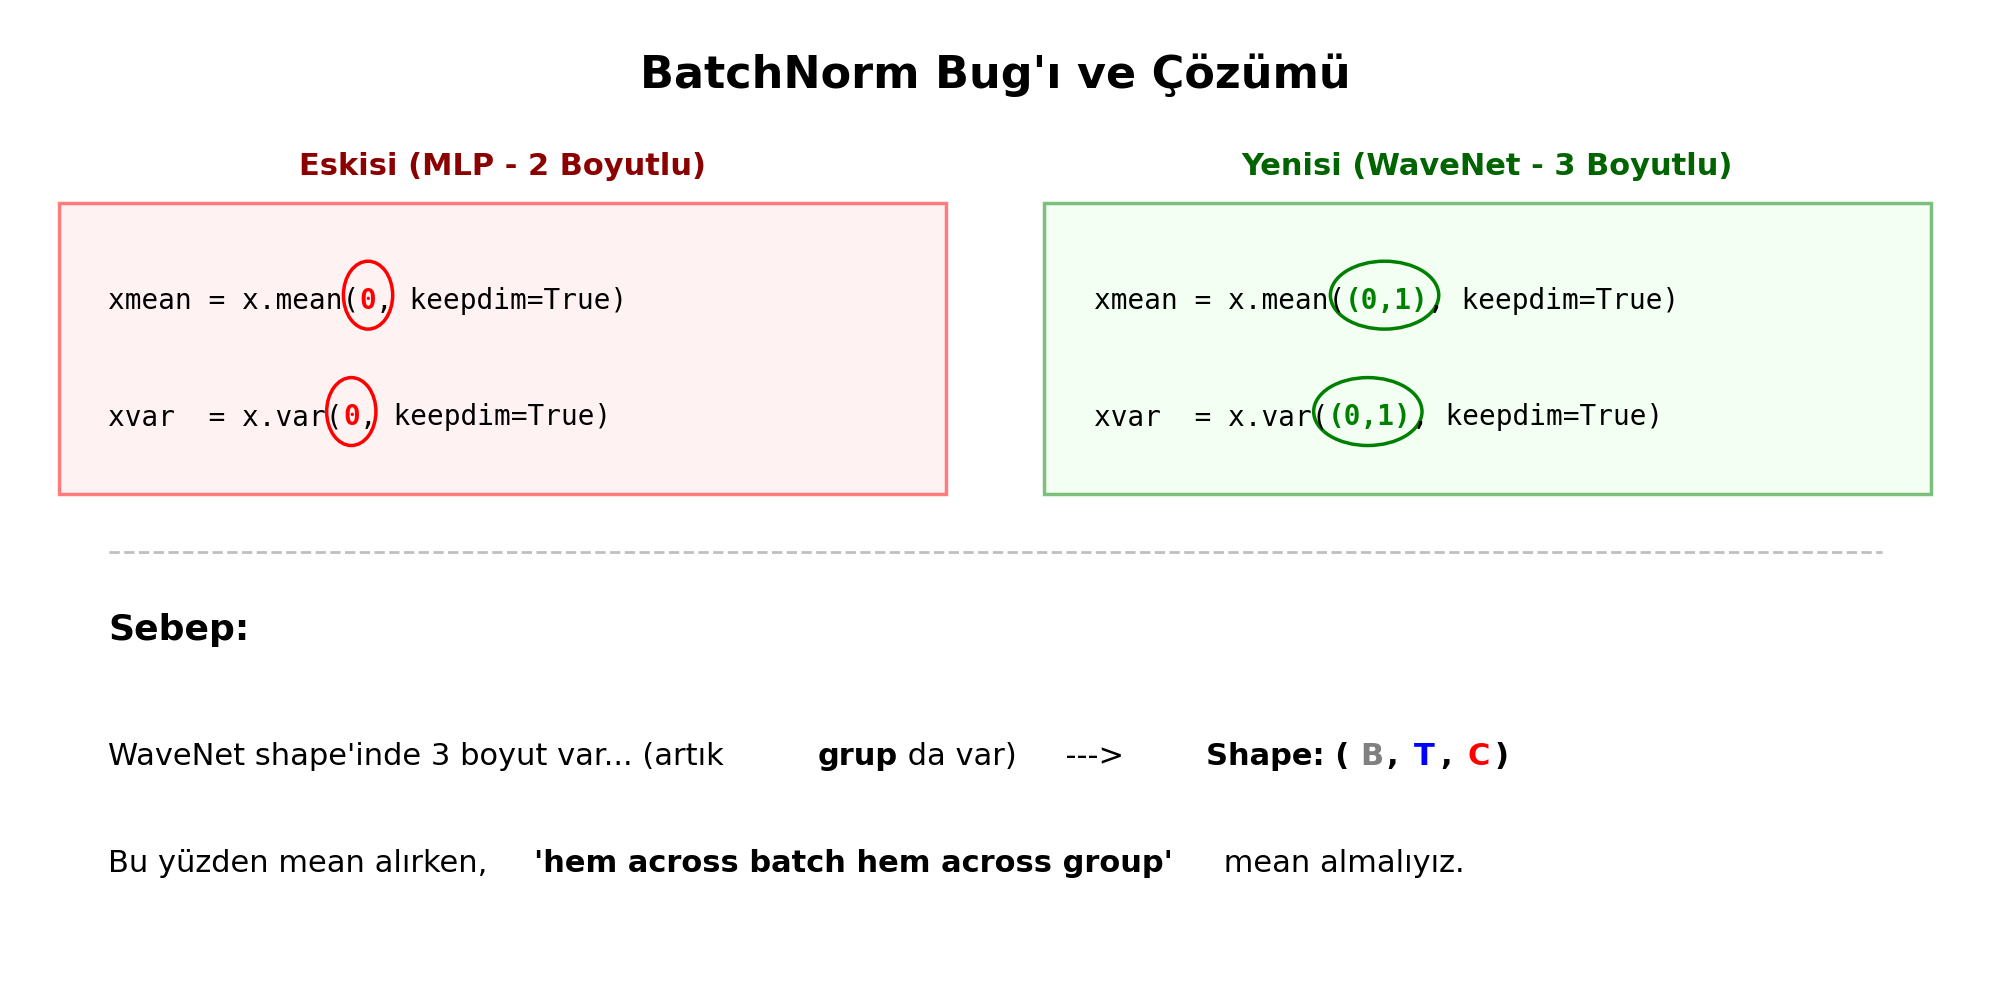

In [ ]:
# görselleştirme
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_batchnorm_bug():
    fig, ax = plt.subplots(figsize=(20, 10))
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # ----------------------------------------------------
    # Başlık
    # ----------------------------------------------------
    ax.text(10, 9.2, "BatchNorm Bug'ı ve Çözümü", fontsize=32, fontweight='bold', ha='center', color='black')
    
    # Yardımcı Fonksiyon: Monospace kod
    def draw_mono_code(ax, x, y, parts):
        current_x = x
        centers = []
        for t, c, b in parts:
            weight = 'bold' if b else 'normal'
            ax.text(current_x, y, t, family='monospace', fontsize=20, fontweight=weight, color=c, ha='left', va='center')
            width = len(t) * 0.17  
            centers.append(current_x + width / 2)
            current_x += width
        return centers

    # Yardımcı Fonksiyon: Akan metin (Mükemmel Harf Genişliği Hassasiyeti)
    def draw_flow_text(ax, x, y, texts_and_styles, fontsize=22):
        current_x = x
        for t, w, c in texts_and_styles:
            ax.text(current_x, y, t, fontsize=fontsize, fontweight=w, color=c, ha='left', va='center')
            w_factor = 1.05 if w == 'bold' else 1.0
            
            for char in t:
                if char in "., ()'\"-": current_x += 0.13 * w_factor
                elif char in "iıl!j": current_x += 0.09 * w_factor
                elif char.isupper(): current_x += 0.26 * w_factor
                elif char in "mwMW": current_x += 0.30 * w_factor
                elif char == ' ': current_x += 0.13 * w_factor
                else: current_x += 0.195 * w_factor

    # ----------------------------------------------------
    # Kutu 1: Eskisi (MLP)
    # ----------------------------------------------------
    rect_old = patches.Rectangle((0.5, 5.0), 9.0, 3.0, fill=True, color='#ffe6e6', lw=2.5, ec='red', alpha=0.5)
    ax.add_patch(rect_old)
    ax.text(5.0, 8.3, "Eskisi (MLP - 2 Boyutlu)", fontsize=22, fontweight='bold', ha='center', color='darkred')
    
    y_line1 = 7.0
    y_line2 = 5.8
    
    parts_old1 = [("xmean = x.mean(", "black", False), ("0", "red", True), (", keepdim=True)", "black", False)]
    centers_old1 = draw_mono_code(ax, 1.0, y_line1, parts_old1)
    
    parts_old2 = [("xvar  = x.var(", "black", False), ("0", "red", True), (", keepdim=True)", "black", False)]
    centers_old2 = draw_mono_code(ax, 1.0, y_line2, parts_old2)
    
    ellipse_old1 = patches.Ellipse((centers_old1[1], y_line1 + 0.05), width=0.5, height=0.7, edgecolor='red', facecolor='none', lw=2.5)
    ax.add_patch(ellipse_old1)
    ellipse_old2 = patches.Ellipse((centers_old2[1], y_line2 + 0.05), width=0.5, height=0.7, edgecolor='red', facecolor='none', lw=2.5)
    ax.add_patch(ellipse_old2)
    
    # ----------------------------------------------------
    # Kutu 2: Yenisi (WaveNet)
    # ----------------------------------------------------
    rect_new = patches.Rectangle((10.5, 5.0), 9.0, 3.0, fill=True, color='#e6ffe6', lw=2.5, ec='green', alpha=0.5)
    ax.add_patch(rect_new)
    ax.text(15.0, 8.3, "Yenisi (WaveNet - 3 Boyutlu)", fontsize=22, fontweight='bold', ha='center', color='darkgreen')
    
    parts_new1 = [("xmean = x.mean(", "black", False), ("(0,1)", "green", True), (", keepdim=True)", "black", False)]
    centers_new1 = draw_mono_code(ax, 11.0, y_line1, parts_new1)
    
    parts_new2 = [("xvar  = x.var(", "black", False), ("(0,1)", "green", True), (", keepdim=True)", "black", False)]
    centers_new2 = draw_mono_code(ax, 11.0, y_line2, parts_new2)
    
    ellipse_new1 = patches.Ellipse((centers_new1[1] - 0.02, y_line1 + 0.05), width=1.1, height=0.7, edgecolor='green', facecolor='none', lw=2.5)
    ax.add_patch(ellipse_new1)
    ellipse_new2 = patches.Ellipse((centers_new2[1] - 0.02, y_line2 + 0.05), width=1.1, height=0.7, edgecolor='green', facecolor='none', lw=2.5)
    ax.add_patch(ellipse_new2)
    
    ax.plot([1.0, 19.0], [4.4, 4.4], color='gray', linestyle='--', lw=2, alpha=0.5)

    # ----------------------------------------------------
    # Sebep Kısmı (Renkli ve Kalın Vurgular)
    # ----------------------------------------------------
    ax.text(1.0, 3.5, "Sebep:", fontsize=26, fontweight='bold', color='black')
    
    texts_line1 = [
        ("WaveNet shape'inde 3 boyut var... (artık ", 'normal', 'black'),
        ("grup", 'bold', 'black'),
        (" da var)     --->    ", 'normal', 'black'),
        ("Shape: (", 'bold', 'black'),
        ("B", 'bold', 'gray'),
        (", ", 'bold', 'black'),
        ("T", 'bold', 'blue'),
        (", ", 'bold', 'black'),
        ("C", 'bold', 'red'),
        (")", 'bold', 'black')
    ]
    
    texts_line2 = [
        ("Bu yüzden mean alırken, ", 'normal', 'black'),
        ("'hem across batch hem across group'", 'bold', 'black'),
        (" mean almalıyız.", 'normal', 'black')
    ]
    
    draw_flow_text(ax, 1.0, 2.3, texts_line1, fontsize=22)
    draw_flow_text(ax, 1.0, 1.2, texts_line2, fontsize=22)
    
    plt.tight_layout()
    plt.show()

# Kodu çalıştırıyoruz
visualize_batchnorm_bug()

In [ ]:
# Görev 5:
    ## Modeli büyüt
        ### Embedding boyutunu ve katman genişliğini artır
    ## Tek tablo çıkar, üç satır olsun:
        ### Bağlam 3 MLP
        ### Bağlam 8 düz MLP
        ### Bağlam 8 WaveNet
    ## Sütunlar parametre sayısı ve dev loss.


## modeli büyüttük
n_embd = 24
n_hidden = 128


## 3 MLP
block_size = 3
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

model = Sequential([
    Embedding(vocab_size, n_embd), Flatten(),
    
    Linear(n_embd*block_size, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
    
    Linear(n_hidden, vocab_size)
])
print(f"3 MLP - Parametre Sayısı: {sum(p.nelement() for p in model.parameters())}")
train_model()
split_loss('train')
split_loss('val')

## 8 düz MLP
block_size = 8
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

model = Sequential([
    Embedding(vocab_size, n_embd), Flatten(),
    
    Linear(n_embd*block_size, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
    
    Linear(n_hidden, vocab_size)
])
print(f"8 MLP - Parametre Sayısı: {sum(p.nelement() for p in model.parameters())}")
train_model()
split_loss('train')
split_loss('val')

## 8 wavenet
kernel_size = 2
model = Sequential([
    Embedding(vocab_size, n_embd),
    
    FlattenConsecutive(kernel_size), Linear(n_embd*kernel_size, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(kernel_size), Linear(n_hidden*kernel_size, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(), 
    FlattenConsecutive(kernel_size), Linear(n_hidden*kernel_size, n_hidden,bias=False), BatchNorm1d(n_hidden), Tanh(), 

    Linear(n_hidden, vocab_size)

])
print(f"8 Wavenet - Parametre Sayısı: {sum(p.nelement() for p in model.parameters())}")
train_model()
split_loss('train')
split_loss('val')

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])
3 MLP - Parametre Sayısı: 30243
train 2.0059611797332764
val 2.079566717147827
torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])
8 MLP - Parametre Sayısı: 45603
train 1.8113877773284912
val 2.0081169605255127
8 Wavenet - Parametre Sayısı: 76579
train 1.7705172300338745
val 1.9893759489059448


In [ ]:
# Görev 6: 
    ## Türkçe isim listenle aynı WaveNet'i eğit
    ## Ürettiği isimlerden örnek ver, dev loss'u hafta 4'ün Türkçe MLP'siyle karşılaştır
    ## Türkçe'de bağlamı 8'e çıkarmak ne kazandırdı, yaz


## OVERFIT EDEN AZ ÖRNEKLİ DATASET
print("------------------  AZ ÖRNEKLİ (3000) DATASET (OVERFIT) ------------------\n\n")
words = open('turkish_names_only.txt', 'r', encoding='utf-8').read().splitlines()
random.seed(42)
random.shuffle(words)

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos) 

# 2. HAZIR FONKSİYONLA VERİ SETİNİ YARAT
block_size = 8
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

n_embd = 24
n_hidden = 128
kernel_size = 2

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(kernel_size), Linear(n_embd*kernel_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(kernel_size), Linear(n_hidden*kernel_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), 
    FlattenConsecutive(kernel_size), Linear(n_hidden*kernel_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), 
    Linear(n_hidden, vocab_size)
])

print(f"Parametre Sayısı: {sum(p.nelement() for p in model.parameters())}")
train_model()

split_loss('train')
split_loss('val')

print("\n--- WaveNet Tarafından Üretilen Örnek Türkçe İsimler ---")
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        x = torch.tensor([context])
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
            
    print(''.join(itos[i] for i in out[:-1]))

print("\n\n\n\n\n\n")

## OVERFIT EDEN AZ ÖRNEKLİ DATASET
print("------------------  BOL ÖRNEKLİ (9000) DATASET (OVERFIT) ------------------\n\n")
words = open('turkish_names_and_generated_names.txt', 'r', encoding='utf-8').read().splitlines()
random.seed(42)
random.shuffle(words)

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos) 

# 2. HAZIR FONKSİYONLA VERİ SETİNİ YARAT
block_size = 8
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

n_embd = 24
n_hidden = 128
kernel_size = 2

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(kernel_size), Linear(n_embd*kernel_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(kernel_size), Linear(n_hidden*kernel_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), 
    FlattenConsecutive(kernel_size), Linear(n_hidden*kernel_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), 
    Linear(n_hidden, vocab_size)
])

print(f"Parametre Sayısı: {sum(p.nelement() for p in model.parameters())}")
train_model()

split_loss('train')
split_loss('val')

print("\n--- WaveNet Tarafından Üretilen Örnek Türkçe İsimler ---")
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        x = torch.tensor([context])
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
            
    print(''.join(itos[i] for i in out[:-1]))

torch.Size([15887, 8]) torch.Size([15887])
torch.Size([1979, 8]) torch.Size([1979])
torch.Size([1960, 8]) torch.Size([1960])
Parametre Sayısı: 77191
train 1.1771628856658936
val 3.037684440612793

--- WaveNet Tarafından Üretilen Örnek Türkçe İsimler ---
viyan
cankaya
hüner
kimya
abdülcevat
selen
meftun
ses
kayhan
egemen
elhan
ilbilge
raşit
olguner
murtaza
aşir
kümnal
destegül
alanur
alican


In [ ]:
# benim farklı yaptıklarım

## class Seuqential içinde "requires_grad yaptım" 
"""
class Sequential:
    def __init__(self, layers):
        self.layers = layers

        ## videoda bu yok, ben buraya koydum ama
        for p in self.parameters():
            p.requires_grad = True
"""

## Linear(bias=False) demeyi unuttum bazı yerlerde

## Görev 4'te, BatchNorm1d'yi update ederken, sadece def __call__() fonk.unu yazmıştım
    ### def __init__() ve def parameters() fonk.ları silinmiş